In [5]:
# Import the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load the raw Ramen dataset

df = pd.read_csv("ramen-ratings.csv")

In [7]:
# Create a working copy

df_clean = df.copy()

In [8]:
# View the first 5 rows

df_clean.head()

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,NaN
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1,NaN
2,2578,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,NaN
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,NaN
4,2576,Ching's Secret,Singapore Curry,Pack,India,3.75,NaN


In [9]:
# View the last 5 rows

df_clean.tail()

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
2575,5,Vifon,"Hu Tiu Nam Vang [""Phnom Penh"" style] Asian Sty...",Bowl,Vietnam,3.5,NaN
2576,4,Wai Wai,Oriental Style Instant Noodles,Pack,Thailand,1,NaN
2577,3,Wai Wai,Tom Yum Shrimp,Pack,Thailand,2,NaN
2578,2,Wai Wai,Tom Yum Chili Flavor,Pack,Thailand,2,NaN
2579,1,Westbrae,Miso Ramen,Pack,USA,0.5,NaN


In [10]:
# Check the dataset shape

df_clean.shape

(2580, 7)

In [11]:
# Check column names

df_clean.columns

Index(['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten'], dtype='str')

In [12]:
# Check basic DataFrame information

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Review #  2580 non-null   int64
 1   Brand     2580 non-null   str  
 2   Variety   2580 non-null   str  
 3   Style     2578 non-null   str  
 4   Country   2580 non-null   str  
 5   Stars     2580 non-null   str  
 6   Top Ten   41 non-null     str  
dtypes: int64(1), str(6)
memory usage: 141.2 KB


In [13]:
# Check the data type of each column

df_clean.dtypes

Review #    int64
Brand         str
Variety       str
Style         str
Country       str
Stars         str
Top Ten       str
dtype: object

In [14]:
# Get a statistical summary

df_clean.describe()

,Review #
count,2580.000000
mean,1290.500000
std,744.926171
min,1.000000
25%,645.750000
50%,1290.500000
75%,1935.250000
max,2580.000000


In [15]:
# Count unique values

df_clean.nunique()

Review #    2580
Brand        355
Variety     2413
Style          7
Country       38
Stars         51
Top Ten       38
dtype: int64

In [16]:
# Check missing values

df_clean.isnull().sum()

Review #       0
Brand          0
Variety        0
Style          2
Country        0
Stars          0
Top Ten     2539
dtype: int64

In [17]:
# Calculate missing-value percentages

(df_clean.isnull().sum() / len(df_clean) * 100).round(2)

Review #     0.00
Brand        0.00
Variety      0.00
Style        0.08
Country      0.00
Stars        0.00
Top Ten     98.41
dtype: float64

In [18]:
# Check duplicate rows

df_clean.duplicated().sum()

np.int64(0)

In [19]:
# Check whether Review # is duplicated

df_clean["Review #"].duplicated().sum()

np.int64(0)

In [20]:
# Check Style categories

df_clean["Style"].unique()

<StringArray>
['Cup', 'Pack', 'Tray', 'Bowl', 'Box', 'Can', 'Bar', nan]
Length: 8, dtype: str

In [21]:
# Count each Style category

df_clean["Style"].value_counts(dropna=False)

Style
Pack    1531
Bowl     481
Cup      450
Tray     108
Box        6
NaN        2
Can        1
Bar        1
Name: count, dtype: int64

In [22]:
# Check Country categories

df_clean["Country"].value_counts().head(15)

Country
Japan          352
USA            323
South Korea    309
Taiwan         224
Thailand       191
China          169
Malaysia       156
Hong Kong      137
Indonesia      126
Singapore      109
Vietnam        108
UK              69
Philippines     47
Canada          41
India           31
Name: count, dtype: int64

In [23]:
# Check Brand frequency

df_clean["Brand"].value_counts().head(15)

Brand
Nissin           381
Nongshim          98
Maruchan          76
Mama              71
Paldo             66
Myojo             63
Indomie           53
Samyang Foods     52
Ottogi            46
Vina Acecook      34
Lucky Me!         34
Vifon             33
Maggi             30
Mamee             29
Master Kong       28
Name: count, dtype: int64

In [24]:
# Check the actual Stars values

df_clean["Stars"].value_counts().head(25)

Stars
4       384
5       369
3.75    350
3.5     326
3       173
3.25    170
4.25    143
4.5     132
2.75     85
2        68
2.5      67
4.75     64
1.5      37
1.75     27
1        26
0        26
2.25     21
0.5      14
0.25     11
5.0      10
1.25     10
3.50      9
5.00      7
4.00      6
4.3       4
Name: count, dtype: int64

In [25]:
# Find non-numeric Stars values

stars_numeric = pd.to_numeric(df_clean["Stars"], errors="coerce")

df_clean.loc[stars_numeric.isnull(), "Stars"].unique()

<StringArray>
['Unrated']
Length: 1, dtype: str

In [26]:
# Convert Stars to a numerical column

df_clean["Stars"] = pd.to_numeric(
    df_clean["Stars"],
    errors="coerce"
)

In [27]:
# Verify the Stars data type

df_clean["Stars"].dtype

dtype('float64')

In [28]:
# Get statistics for Stars

df_clean["Stars"].describe()

count    2577.000000
mean        3.654676
std         1.015331
min         0.000000
25%         3.250000
50%         3.750000
75%         4.250000
max         5.000000
Name: Stars, dtype: float64

In [29]:
# View rows where Style is missing

df_clean[df_clean["Style"].isnull()]

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
2152,428,Kamfen,E Menm Chicken,NaN,China,3.75,NaN
2442,138,Unif,100 Furong Shrimp,NaN,Taiwan,3.00,NaN


In [30]:
# Inspect the missing Style records

df_clean.loc[
    df_clean["Style"].isnull(),
    ["Brand", "Variety", "Country", "Stars"]
]

,Brand,Variety,Country,Stars
2152,Kamfen,E Menm Chicken,China,3.75
2442,Unif,100 Furong Shrimp,Taiwan,3.00


In [31]:
# Fill missing Style values

df_clean["Style"] = df_clean["Style"].fillna(
    df_clean["Style"].mode()[0]
)

In [32]:
# Inspect Top Ten values

df_clean["Top Ten"].value_counts(dropna=False).head(20)

Top Ten
NaN         2539
\n             4
2016 #10       1
2016 #1        1
2016 #8        1
2016 #5        1
2016 #9        1
2016 #7        1
2015 #10       1
2015 #7        1
2015 #4        1
2015 #9        1
2015 #6        1
2015 #1        1
2013 #10       1
2015 #8        1
2014 #7        1
2014 #4        1
2014 #9        1
2014 #10       1
Name: count, dtype: int64

In [33]:
# View actual Top Ten records

df_clean.loc[
    df_clean["Top Ten"].notna() &
    (df_clean["Top Ten"].str.strip() != ""),
    ["Brand", "Variety", "Top Ten"]
]

,Brand,Variety,Top Ten
616,MAMA,Instant Noodles Coconut Milk Flavour,2016 #10
633,Prima Taste,Singapore Laksa Wholegrain La Mian,2016 #1
655,Prima,Juzz's Mee Creamy Chicken Flavour,2016 #8
673,Prima Taste,Singapore Curry Wholegrain La Mian,2016 #5
752,Tseng Noodles,Scallion With Sichuan Pepper Flavor,2016 #9
891,Wugudaochang,Tomato Beef Brisket Flavor Purple Potato Noodle,2016 #7
942,A-Sha Dry Noodle,Veggie Noodle Tomato Noodle With Vine Ripened ...,2015 #10
963,MyKuali,Penang Hokkien Prawn Noodle (New Improved Taste),2015 #7
995,CarJEN,Nyonya Curry Laksa,2015 #4
1059,Maruchan,Gotsumori Sauce Yakisoba,2015 #9


In [34]:
# Create an Is_Top_Ten column

df_clean["Is_Top_Ten"] = (
    df_clean["Top Ten"].notna() &
    (df_clean["Top Ten"].str.strip() != "")
).astype(int)

In [35]:
# Verify Is_Top_Ten

df_clean["Is_Top_Ten"].value_counts()

Is_Top_Ten
0    2543
1      37
Name: count, dtype: int64

In [36]:
# Drop the original Top Ten column

df_clean = df_clean.drop("Top Ten", axis=1)

In [37]:
# Check duplicates after transformations

df_clean.duplicated().sum()

np.int64(0)

In [38]:
# Remove unnecessary spaces from text columns

text_columns = ["Brand", "Variety", "Style", "Country"]

for col in text_columns:
    df_clean[col] = df_clean[col].str.strip()

In [39]:
# Create a cleaned Brand column

df_clean["Brand"] = df_clean["Brand"].str.strip().str.title()

In [40]:
# Create a Rating Category

df_clean["Rating Category"] = pd.cut(
    df_clean["Stars"],
    bins=[-0.01, 2, 3, 4, 5],
    labels=["Low", "Fair", "Good", "Excellent"],
    include_lowest=True
)

In [41]:
# Create a simple Top Ten status label

df_clean["Top Ten Status"] = np.where(
    df_clean["Is_Top_Ten"] == 1,
    "Top Ten",
    "Not Top Ten"
)

In [42]:
# Calculate the average ramen rating

df_clean["Stars"].mean()

np.float64(3.6546759798214974)

In [43]:
# Find the highest-rated ramen products

df_clean.sort_values(
    by="Stars",
    ascending=False
).head(10)

,Review #,Brand,Variety,Style,Country,Stars,Is_Top_Ten,Rating Category,Top Ten Status
2552,28,Nissin,Chikin Ramen,Pack,Japan,5.0,0,Excellent,Not Top Ten
30,2550,Samyang Foods,Paegaejang Ramen,Pack,South Korea,5.0,0,Excellent,Not Top Ten
10,2570,Tao Kae Noi,Creamy tom Yum Kung Flavour,Pack,Thailand,5.0,0,Excellent,Not Top Ten
11,2569,Yamachan,Yokohama Tonkotsu Shoyu,Pack,USA,5.0,0,Excellent,Not Top Ten
28,2552,Mykuali,Penang White Curry Rice Vermicelli Soup,Bowl,Malaysia,5.0,0,Excellent,Not Top Ten
1148,1432,Maggi,Senses Laksa Instant Noodles,Pack,Singapore,5.0,0,Excellent,Not Top Ten
596,1984,Nissin,Chinese Tan Tan Vermicelli,Cup,Hong Kong,5.0,0,Excellent,Not Top Ten
595,1985,Prima Taste,Singapore Prawn Soup La Mian,Pack,Singapore,5.0,0,Excellent,Not Top Ten
1793,787,Emart,Ramen E Ramen White Broth,Pack,South Korea,5.0,0,Excellent,Not Top Ten
590,1990,Nissin,Cup Noodle,Cup,Japan,5.0,0,Excellent,Not Top Ten


In [44]:
# Find the most reviewed brands

df_clean["Brand"].value_counts().head(15)

Brand
Nissin           381
Nongshim          98
Mama              98
Maruchan          76
Paldo             66
Myojo             63
Indomie           53
Samyang Foods     52
Ottogi            46
Koka              43
Vina Acecook      34
Lucky Me!         34
Vifon             33
Maggi             30
Mamee             29
Name: count, dtype: int64

In [45]:
# Calculate average rating by Brand

df_clean.groupby("Brand")["Stars"].mean().sort_values(ascending=False).head(20)

Brand
The Ramen Rater Select    5.0
The Bridge                5.0
Daddy                     5.0
Daifuku                   5.0
Torishi                   5.0
Takamori                  5.0
Tao Kae Noi               5.0
Choripdong                5.0
Kimura                    5.0
Komforte Chockolates      5.0
Nyor Nyar                 5.0
Oree Garden               5.0
Myori                     5.0
Peyang                    5.0
Prima                     5.0
Jackpot Teriyaki          5.0
Higashi                   5.0
Kiki Noodle               5.0
Prima Taste               5.0
Patanjali                 5.0
Name: Stars, dtype: float64

In [46]:
# Count reviews by Country

df_clean["Country"].value_counts().head(15)

Country
Japan          352
USA            323
South Korea    309
Taiwan         224
Thailand       191
China          169
Malaysia       156
Hong Kong      137
Indonesia      126
Singapore      109
Vietnam        108
UK              69
Philippines     47
Canada          41
India           31
Name: count, dtype: int64

In [47]:
# Calculate average rating by Country

df_clean.groupby("Country")["Stars"].mean().sort_values(ascending=False).head(20)

Country
Brazil           4.350000
Sarawak          4.333333
Cambodia         4.200000
Malaysia         4.154194
Singapore        4.126147
Indonesia        4.067460
Japan            3.981605
Myanmar          3.946429
Fiji             3.875000
Hong Kong        3.801825
South Korea      3.790554
United States    3.750000
Mexico           3.730000
Bangladesh       3.714286
Taiwan           3.665402
Germany          3.638889
Poland           3.625000
Hungary          3.611111
Dubai            3.583333
Finland          3.583333
Name: Stars, dtype: float64

In [48]:
# Calculate average rating by Style

df_clean.groupby("Style", observed=False)["Stars"].mean().sort_values(ascending=False)

Style
Bar     5.000000
Box     4.291667
Pack    3.700033
Bowl    3.670686
Tray    3.545139
Can     3.500000
Cup     3.498500
Name: Stars, dtype: float64

In [49]:
# Count reviews for each Brand

brand_counts = df_clean.groupby("Brand").size().sort_values(ascending=False)

brand_counts.head(20)

Brand
Nissin              381
Nongshim             98
Mama                 98
Maruchan             76
Paldo                66
Myojo                63
Indomie              53
Samyang Foods        52
Ottogi               46
Koka                 43
Vina Acecook         34
Lucky Me!            34
Vifon                33
Maggi                30
Mamee                29
Master Kong          28
A-Sha Dry Noodle     26
Sapporo Ichiban      25
Wai Wai              25
Ve Wong              24
dtype: int64

In [50]:
# Keep brands with at least 10 reviews

brand_counts[brand_counts >= 10]

Brand
Nissin              381
Nongshim             98
Mama                 98
Maruchan             76
Paldo                66
Myojo                63
Indomie              53
Samyang Foods        52
Ottogi               46
Koka                 43
Vina Acecook         34
Lucky Me!            34
Vifon                33
Maggi                30
Mamee                29
Master Kong          28
A-Sha Dry Noodle     26
Sapporo Ichiban      25
Wai Wai              25
Ve Wong              24
Mykuali              24
Jml                  23
Samyang              19
Batchelors           16
Doll                 16
Acecook              15
Kamfen               15
Mr. Noodles          15
Wei Lih              15
Asian Thai Foods     14
Sau Tao              14
Takamori Kosan       14
Little Cook          14
Unif                 13
Dragonfly            13
Saigon Ve Wong       13
Deshome              13
Vit'S                13
Annie Chun'S         12
Abc                  12
Yum Yum              12
Uni-Presid

In [51]:
# Compare ratings of brands with enough reviews

brand_avg_rating = (
    df_clean.groupby("Brand")["Stars"]
    .mean()
)

brand_avg_rating[brand_counts >= 10].sort_values(
    ascending=False
).head(20)

Brand
Mykuali             4.947917
Yamachan            4.568182
Vit'S               4.211538
Abc                 4.208333
Sakurai Foods       4.175000
Takamori Kosan      4.160714
Mi Sedaap           4.145833
Deshome             4.134615
Wugudaochang        4.125000
Indomie             4.070755
Samyang Foods       4.068627
A-Sha Dry Noodle    4.067308
Dragonfly           4.057692
Paldo               4.018939
Koka                4.017442
Nongshim            4.000000
Sichuan Baijia      4.000000
Uni-President       3.958333
Amianda             3.950000
Mamee               3.939655
Name: Stars, dtype: float64

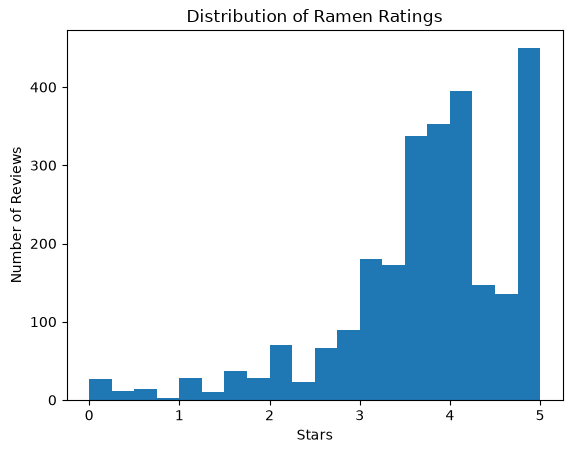

In [52]:
# Plot the distribution of Stars

plt.hist(df_clean["Stars"].dropna(), bins=20)

plt.xlabel("Stars")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Ramen Ratings")

plt.show()

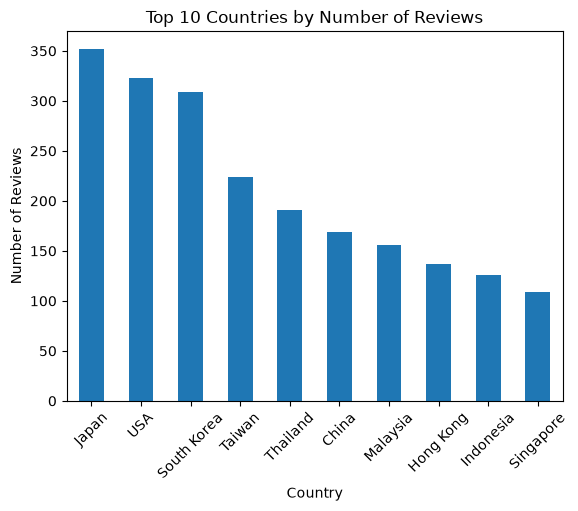

In [53]:
# Plot the top countries by review count

country_counts = df_clean["Country"].value_counts().head(10)

country_counts.plot(kind="bar")

plt.xlabel("Country")
plt.ylabel("Number of Reviews")
plt.title("Top 10 Countries by Number of Reviews")

plt.xticks(rotation=45)
plt.show()

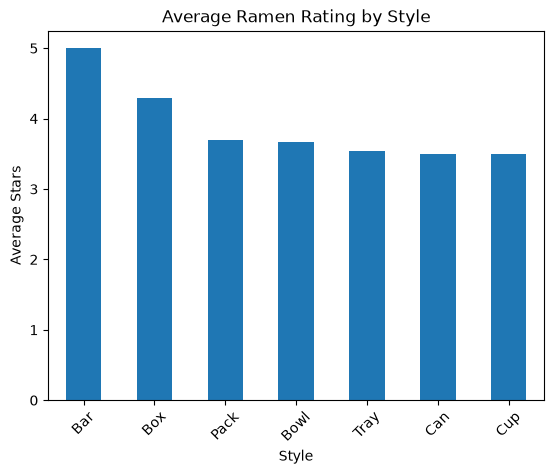

In [54]:
# Plot average rating by Style

style_avg = df_clean.groupby("Style", observed=False)["Stars"].mean()

style_avg.sort_values(ascending=False).plot(kind="bar")

plt.xlabel("Style")
plt.ylabel("Average Stars")
plt.title("Average Ramen Rating by Style")

plt.xticks(rotation=45)
plt.show()

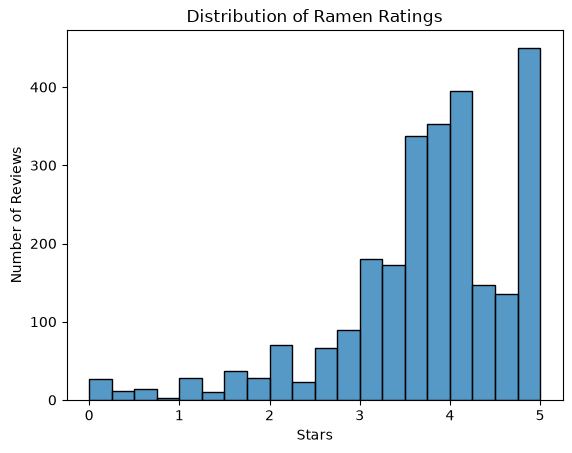

In [55]:
# Visualize rating distribution with Seaborn

sns.histplot(
    data=df_clean,
    x="Stars",
    bins=20
)

plt.xlabel("Stars")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Ramen Ratings")

plt.show()

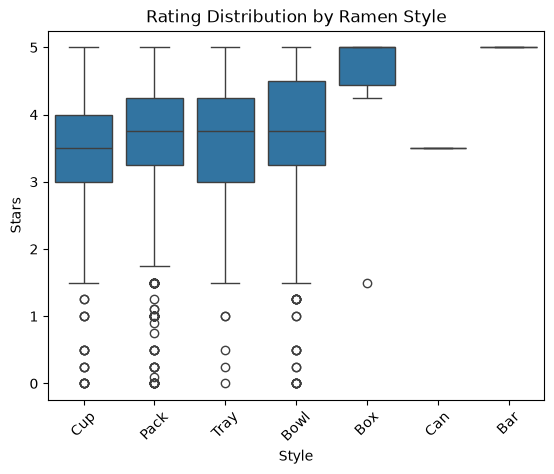

In [56]:
# Compare rating distributions by Style

sns.boxplot(
    data=df_clean,
    x="Style",
    y="Stars"
)

plt.xlabel("Style")
plt.ylabel("Stars")
plt.title("Rating Distribution by Ramen Style")

plt.xticks(rotation=45)
plt.show()

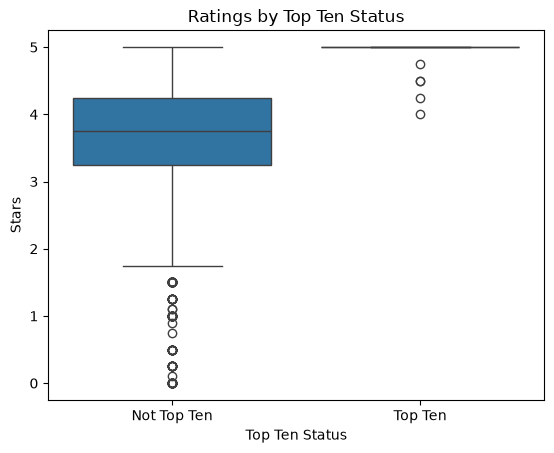

In [57]:
# Compare ratings by Top Ten status

sns.boxplot(
    data=df_clean,
    x="Top Ten Status",
    y="Stars"
)

plt.xlabel("Top Ten Status")
plt.ylabel("Stars")
plt.title("Ratings by Top Ten Status")

plt.show()

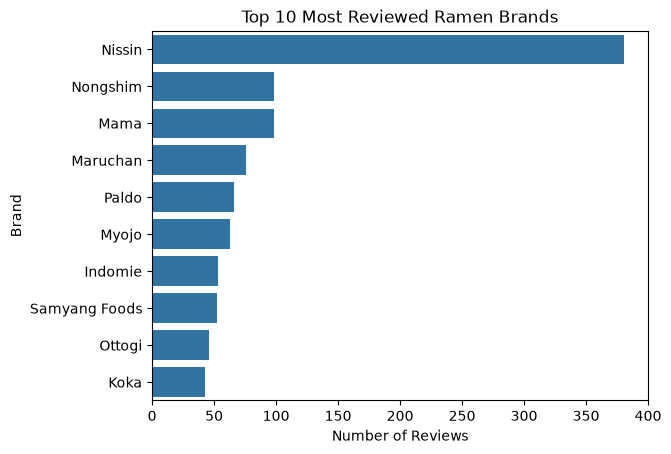

In [58]:
# Visualize the most reviewed brands

top_brands = df_clean["Brand"].value_counts().head(10)

sns.barplot(
    x=top_brands.values,
    y=top_brands.index
)

plt.xlabel("Number of Reviews")
plt.ylabel("Brand")
plt.title("Top 10 Most Reviewed Ramen Brands")

plt.show()

In [59]:
# Compare Brand review count and average rating

brand_summary = df_clean.groupby("Brand").agg(
    Review_Count=("Stars", "count"),
    Average_Rating=("Stars", "mean")
)

brand_summary.sort_values(
    by="Review_Count",
    ascending=False
).head(20)

,Review_Count,Average_Rating
Brand,,
Nissin,381,3.918570
Nongshim,98,4.000000
Mama,98,3.703061
Maruchan,76,3.554276
Paldo,66,4.018939
Myojo,63,3.801587
Indomie,53,4.070755
Samyang Foods,51,4.068627
Ottogi,45,3.394444


In [60]:
# Find highly rated brands with enough reviews

brand_summary[
    brand_summary["Review_Count"] >= 10
].sort_values(
    by="Average_Rating",
    ascending=False
).head(20)

,Review_Count,Average_Rating
Brand,,
Mykuali,24,4.947917
Yamachan,11,4.568182
Vit'S,13,4.211538
Abc,12,4.208333
Sakurai Foods,10,4.175000
Takamori Kosan,14,4.160714
Mi Sedaap,12,4.145833
Deshome,13,4.134615
Wugudaochang,10,4.125000


In [61]:
# Create a country summary

country_summary = df_clean.groupby("Country").agg(
    Review_Count=("Stars", "count"),
    Average_Rating=("Stars", "mean")
)

country_summary.sort_values(
    by="Review_Count",
    ascending=False
).head(20)

,Review_Count,Average_Rating
Country,,
Japan,352,3.981605
USA,323,3.457043
South Korea,307,3.790554
Taiwan,224,3.665402
Thailand,191,3.384817
China,169,3.421893
Malaysia,155,4.154194
Hong Kong,137,3.801825
Indonesia,126,4.067460


In [62]:
# Compare countries with at least 20 rated reviews

country_summary[
    country_summary["Review_Count"] >= 20
].sort_values(
    by="Average_Rating",
    ascending=False
)

,Review_Count,Average_Rating
Country,,
Malaysia,155,4.154194
Singapore,109,4.126147
Indonesia,126,4.067460
Japan,352,3.981605
Hong Kong,137,3.801825
South Korea,307,3.790554
Mexico,25,3.730000
Taiwan,224,3.665402
Germany,27,3.638889


In [63]:
# Analyze average rating by Country and Style

df_clean.groupby(
    ["Country", "Style"],
    observed=False
)["Stars"].mean().sort_values(ascending=False).head(30)

Country        Style
USA            Bar      5.000000
Malaysia       Box      5.000000
Japan          Box      5.000000
Brazil         Cup      4.500000
Japan          Tray     4.375000
Sarawak        Pack     4.333333
Malaysia       Bowl     4.281250
Brazil         Pack     4.250000
Indonesia      Box      4.250000
Singapore      Pack     4.210145
Cambodia       Pack     4.200000
Malaysia       Pack     4.156452
Japan          Bowl     4.140278
Singapore      Bowl     4.096154
Indonesia      Pack     4.091346
Myanmar        Cup      4.083333
Hong Kong      Cup      4.039474
Malaysia       Cup      4.011905
Japan          Cup      3.940816
Indonesia      Cup      3.940476
Singapore      Cup      3.925926
Myanmar        Pack     3.909091
Fiji           Pack     3.875000
South Korea    Bowl     3.865809
               Pack     3.857459
Japan          Pack     3.801613
Taiwan         Pack     3.757143
Vietnam        Tray     3.750000
Thailand       Tray     3.750000
United States  Pack   

In [64]:
# Analyze Brand and Style together

df_clean.groupby(
    ["Brand", "Style"],
    observed=False
)["Stars"].mean().sort_values(ascending=False).head(30)

Brand                   Style
Ttl                     Bowl     5.0
Torishi                 Pack     5.0
Mykuali                 Bowl     5.0
Daifuku                 Bowl     5.0
The Bridge              Pack     5.0
The Ramen Rater Select  Box      5.0
Daddy                   Pack     5.0
Oree Garden             Bowl     5.0
Tao Kae Noi             Pack     5.0
Takamori                Pack     5.0
Nyor Nyar               Pack     5.0
Choripdong              Bowl     5.0
Myori                   Pack     5.0
Mykuali                 Box      5.0
Daikoku                 Tray     5.0
Plats Du Chef           Bowl     5.0
Peyang                  Tray     5.0
Foodmon                 Bowl     5.0
Sempio                  Pack     5.0
Seven & I               Bowl     5.0
Kiki Noodle             Pack     5.0
Kimura                  Pack     5.0
Jackpot Teriyaki        Pack     5.0
Higashi                 Pack     5.0
Sapporo Ichiban         Tray     5.0
Prima Taste             Pack     5.0
Prima   

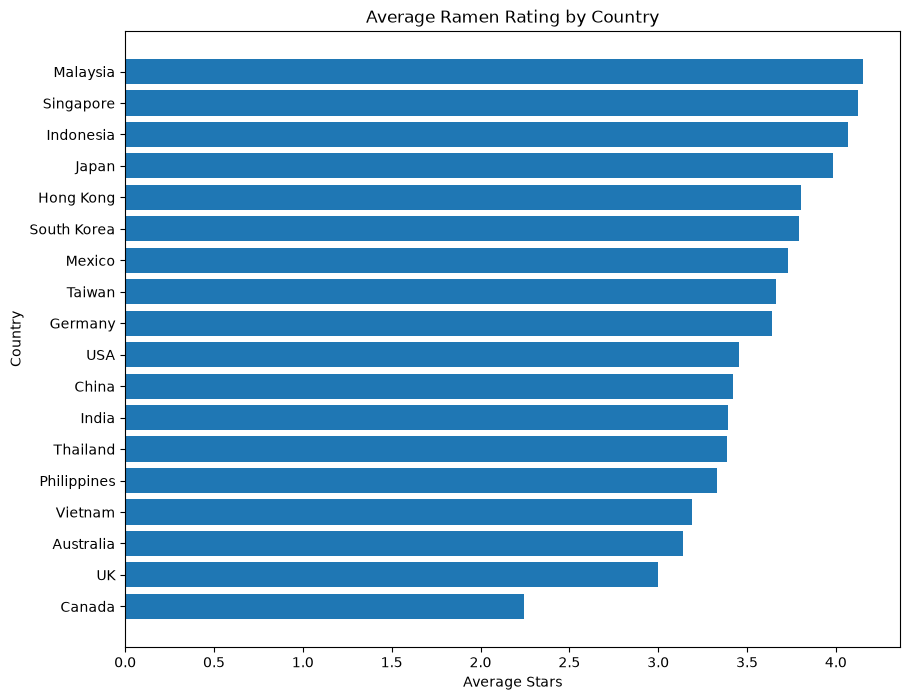

In [65]:
# Plot average rating by Country

country_plot = country_summary[
    country_summary["Review_Count"] >= 20
].sort_values(
    by="Average_Rating",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    country_plot.index,
    country_plot["Average_Rating"]
)

plt.xlabel("Average Stars")
plt.ylabel("Country")
plt.title("Average Ramen Rating by Country")

plt.show()

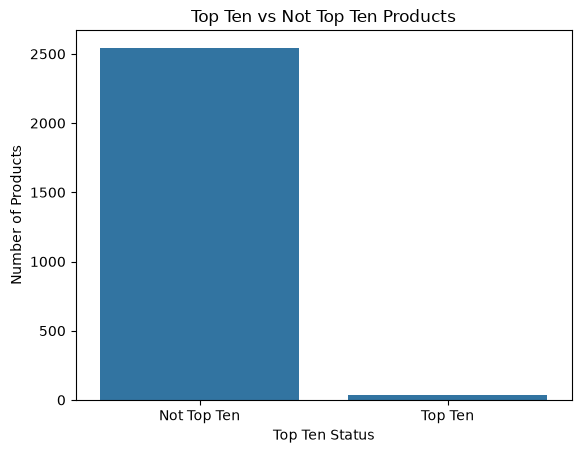

In [66]:
# Plot Top Ten status

sns.countplot(
    data=df_clean,
    x="Top Ten Status"
)

plt.xlabel("Top Ten Status")
plt.ylabel("Number of Products")
plt.title("Top Ten vs Not Top Ten Products")

plt.show()

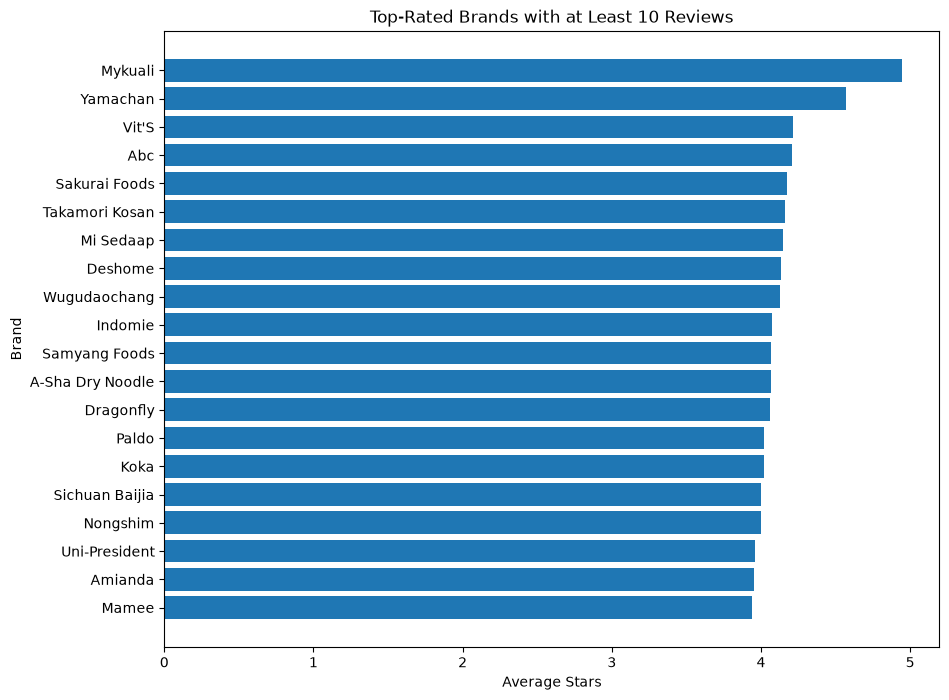

In [67]:
# Plot average rating of sufficiently reviewed brands

brand_plot = brand_summary[
    brand_summary["Review_Count"] >= 10
].sort_values(
    by="Average_Rating",
    ascending=True
).tail(20)

plt.figure(figsize=(10, 8))

plt.barh(
    brand_plot.index,
    brand_plot["Average_Rating"]
)

plt.xlabel("Average Stars")
plt.ylabel("Brand")
plt.title("Top-Rated Brands with at Least 10 Reviews")

plt.show()

In [68]:
# Check remaining missing values

df_clean.isnull().sum()

Review #           0
Brand              0
Variety            0
Style              0
Country            0
Stars              3
Is_Top_Ten         0
Rating Category    3
Top Ten Status     0
dtype: int64

In [69]:
# Check the remaining unrated records

df_clean[df_clean["Stars"].isnull()]

,Review #,Brand,Variety,Style,Country,Stars,Is_Top_Ten,Rating Category,Top Ten Status
32,2548,Ottogi,Plain Instant Noodle No Soup Included,Pack,South Korea,NaN,0,NaN,Not Top Ten
122,2458,Samyang Foods,Sari Ramen,Pack,South Korea,NaN,0,NaN,Not Top Ten
993,1587,Mi E-Zee,Plain Noodles,Pack,Malaysia,NaN,0,NaN,Not Top Ten


In [70]:
# Keep unrated products as missing Stars

df_clean["Stars"].isnull().sum()

np.int64(3)

In [71]:
# Check final dataset shape

df_clean.shape

(2580, 9)

In [72]:
# Check final data types

df_clean.dtypes

Review #              int64
Brand                   str
Variety                 str
Style                   str
Country                 str
Stars               float64
Is_Top_Ten            int64
Rating Category    category
Top Ten Status          str
dtype: object

In [73]:
# View the final dataset

df_clean.head()

,Review #,Brand,Variety,Style,Country,Stars,Is_Top_Ten,Rating Category,Top Ten Status
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,0,Good,Not Top Ten
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1.00,0,Low,Not Top Ten
2,2578,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,0,Fair,Not Top Ten
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,0,Fair,Not Top Ten
4,2576,Ching'S Secret,Singapore Curry,Pack,India,3.75,0,Good,Not Top Ten


In [74]:
# Save the cleaned dataset

df_clean.to_csv(
    "ramen_ratings_cleaned.csv",
    index=False
)